# BCSE209P Machine Learning-(FALL 2026) Laboratory Template

## SCOPE, VIT Chennai

### Student Information

- **Student Name:** Shrri Dharshan D R
- **Register Number:** 23BPS1090
- **Course Code:** BCSE209P
- **Course Title:** Machine Learning Laboratory
- **Faculty:** Dr. S. Shridevi
- **Experiment No.:** 4
- **Date:** 05/08/2026

---

In [1]:
# Student Identification

AUTHOR        = "Shrri Dharshan D R"
REGISTER_NO   = "23BPS1090"
COURSE        = "BCSE209P-Machine Learning Laboratory"
FACULTY       = "Dr. S. Shridevi"
INSTITUTION   = "SCOPE, VIT Chennai"
NOTEBOOK_ID   = "ML-LAB-04"

print("Notebook Loaded Successfully")

Notebook Loaded Successfully


In [2]:
# Notebook Fingerprint

import hashlib
import datetime

fingerprint = hashlib.sha256(
    (AUTHOR + REGISTER_NO + COURSE + NOTEBOOK_ID +
     str(datetime.datetime.now())).encode()
).hexdigest()

print("Notebook Fingerprint:")
print(fingerprint)

Notebook Fingerprint:
b5dc9db840a9cf0ab73915c573f4a00ab69ab1fa9d5cd636cb3d5aae48ae8833


# Experiment Details

## Objective

To study and implement a **K-Nearest Neighbors (KNN) Classifier** using the *Dry Bean* dataset
(UCI ML Repository, ID: 602), in order to classify dry bean grains into one of **seven
registered varieties** (Seker, Barbunya, Bombay, Cali, Dermosan, Horoz, Sira) based on
morphological features extracted via computer vision, and to evaluate the model using
standard multi-class classification metrics (Accuracy, Precision, Recall, F1-Score)
along with optimal K selection and distance metric comparison.

## Theory

**K-Nearest Neighbors (KNN)** is a non-parametric, instance-based supervised learning algorithm
that classifies a new data point by majority vote among its **K closest training samples** in
the feature space. It makes no assumptions about the underlying data distribution (lazy learner).

**Distance Metrics:**

- **Euclidean Distance** (default) — straight-line distance between two points:

$$d(x, x') = \sqrt{\sum_{i=1}^{n} (x_i - x'_i)^2}$$

- **Manhattan Distance** — sum of absolute differences:

$$d(x, x') = \sum_{i=1}^{n} |x_i - x'_i|$$

**Prediction Rule:**
Given a query point $x_q$, find the K training points nearest to $x_q$ and assign the
majority class label among those K neighbors.

**Tie Resolution:**
When votes are equal across classes, **Inverse Distance Weighted (IDW) Voting** is used —
each neighbor's vote is weighted by $\frac{1}{d}$, giving closer neighbors more influence.

**Choosing K:**
- Small K → low bias, high variance (overfitting)
- Large K → high bias, low variance (underfitting)
- Optimal K is found by plotting test accuracy vs K values (elbow method)

**Feature Scaling:**
KNN is distance-based, so features on different scales dominate the distance calculation.
The Dry Bean dataset contains features ranging from pixel counts (Area ~50,000+) to
shape ratios (Eccentricity ~0–1). **StandardScaler** (z-score normalisation) is essential:
$$z = \frac{x - \mu}{\sigma}$$

**Multi-class Classification:**
KNN handles multi-class problems natively through majority voting among K neighbors.
Evaluation uses **macro-averaging** (equal weight per class) across all 7 bean varieties.

**Evaluation Metrics (Multi-class):**
- **Accuracy** — $\frac{\text{Correct Predictions}}{\text{Total Predictions}}$
- **Precision (macro)** — average precision across all 7 classes
- **Recall (macro)** — average recall across all 7 classes
- **F1-Score (macro)** — harmonic mean of macro precision and recall

## Dataset

- **Name:** Dry Bean Dataset
- **Source:** UCI Machine Learning Repository (ID: 602)  
  — https://archive.ics.uci.edu/dataset/602/dry+bean+dataset
- **Total Instances:** 13,611 bean grain images
- **Features (16):** Area, Perimeter, MajorAxisLength, MinorAxisLength, AspectRatio,
  Eccentricity, ConvexArea, EquivDiameter, Extent, Solidity, Roundness,
  Compactness, ShapeFactor1, ShapeFactor2, ShapeFactor3, ShapeFactor4
- **Target:** Class — bean variety (Seker, Barbunya, Bombay, Cali, Dermosan, Horoz, Sira)
- **Class Distribution:** Moderately balanced across 7 classes
- **Missing Values:** None
- **Task Type:** Multi-class Classification (7 classes)
- **Licence:** CC BY 4.0

In [3]:
# Step 1 — Import required libraries

import sys
!{sys.executable} -m pip install ucimlrepo --quiet

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

pd.set_option("display.max_columns", None)
print("All libraries imported successfully.")


[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


All libraries imported successfully.


In [4]:
# Step 2 — Download and load the UCI Dry Bean dataset (ID: 602)

from ucimlrepo import fetch_ucirepo

dry_bean = fetch_ucirepo(id=602)

X_raw = dry_bean.data.features
y_raw = dry_bean.data.targets

# Combine into one DataFrame for EDA
# .ravel() flattens y from 2D (13611,1) to 1D (13611,) — fixes the ValueError
df_raw = X_raw.copy()
df_raw["Class"] = y_raw.values.ravel()

print("Dataset loaded successfully.")
print(df_raw.head())

Dataset loaded successfully.
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRatio  \
0  28395    610.291       208.178117       173.888747     1.197191   
1  28734    638.018       200.524796       182.734419     1.097356   
2  29380    624.110       212.826130       175.931143     1.209713   
3  30008    645.884       210.557999       182.516516     1.153638   
4  30140    620.134       201.847882       190.279279     1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  Roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272751  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0

In [5]:
# Step 3 — Dataset overview

print("Dataset : Dry Bean")
print("Samples :", df_raw.shape[0])
print("Columns :", df_raw.shape[1])
print("Source  : UCI ML Repository (ID: 602)")
print("Target  : Class (7 bean varieties)")

Dataset : Dry Bean
Samples : 13611
Columns : 17
Source  : UCI ML Repository (ID: 602)
Target  : Class (7 bean varieties)


In [6]:
# Step 4 — Explore dataset structure

print("Shape:", df_raw.shape)
print("\nColumn names:", df_raw.columns.tolist())
print("\nFirst 10 rows:")
print(df_raw.head(10))

Shape: (13611, 17)

Column names: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']

First 10 rows:
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRatio  \
0  28395    610.291       208.178117       173.888747     1.197191   
1  28734    638.018       200.524796       182.734419     1.097356   
2  29380    624.110       212.826130       175.931143     1.209713   
3  30008    645.884       210.557999       182.516516     1.153638   
4  30140    620.134       201.847882       190.279279     1.060798   
5  30279    634.927       212.560556       181.510182     1.171067   
6  30477    670.033       211.050155       184.039050     1.146768   
7  30519    629.727       212.996755       182.737204     1.165591   
8  30685    635.681       213.534145       183.157146     1.165852   
9  30

In [7]:
# Step 5 — Data types and unique value counts

print("Dataset Info:")
df_raw.info()
print("\nData Types:")
print(df_raw.dtypes)
print("\nUnique Values per Column:")
print(df_raw.nunique())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRatio      13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  Roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float6

In [8]:
# Step 6 — Check for missing values

missing = df_raw.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")
print("\nTotal missing values:", df_raw.isnull().sum().sum())

Missing values per column:
No missing values found.

Total missing values: 0


Target variable distribution (Class):
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Class proportions (%):
Class
DERMASON    26.05
SIRA        19.37
SEKER       14.89
HOROZ       14.17
CALI        11.98
BARBUNYA     9.71
BOMBAY       3.84
Name: proportion, dtype: float64


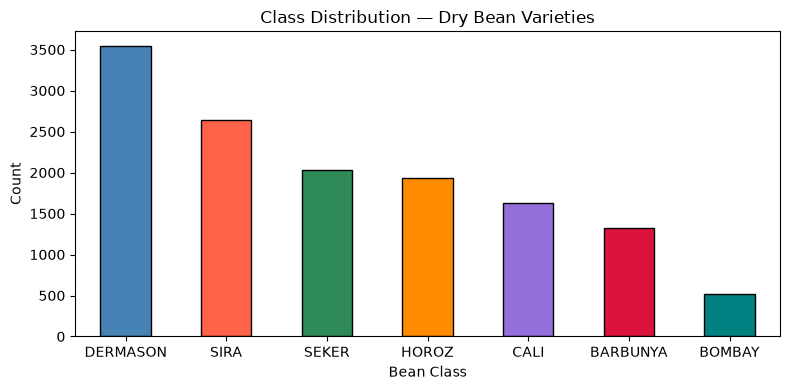

In [9]:
# Step 7 — Target class distribution

print("Target variable distribution (Class):")
print(df_raw["Class"].value_counts())
print("\nClass proportions (%):")
print(round(df_raw["Class"].value_counts(normalize=True) * 100, 2))

plt.figure(figsize=(8, 4))
df_raw["Class"].value_counts().plot(
    kind="bar",
    color=["steelblue", "tomato", "seagreen", "darkorange", "mediumpurple", "crimson", "teal"],
    edgecolor="black"
)
plt.title("Class Distribution — Dry Bean Varieties")
plt.xlabel("Bean Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
# Step 8 — Statistical summary

print("Statistical Summary (Numerical Features):")
print(df_raw.describe())
print("\nStatistical Summary (Target):")
print(df_raw[["Class"]].describe(include="object"))

Statistical Summary (Numerical Features):
                Area     Perimeter  MajorAxisLength  MinorAxisLength  \
count   13611.000000  13611.000000     13611.000000     13611.000000   
mean    53048.284549    855.283459       320.141867       202.270714   
std     29324.095717    214.289696        85.694186        44.970091   
min     20420.000000    524.736000       183.601165       122.512653   
25%     36328.000000    703.523500       253.303633       175.848170   
50%     44652.000000    794.941000       296.883367       192.431733   
75%     61332.000000    977.213000       376.495012       217.031741   
max    254616.000000   1985.370000       738.860154       460.198497   

        AspectRatio  Eccentricity     ConvexArea  EquivDiameter        Extent  \
count  13611.000000  13611.000000   13611.000000   13611.000000  13611.000000   
mean       1.583242      0.750895   53768.200206     253.064220      0.749733   
std        0.246678      0.092002   29774.915817      59.177120   

C:\Users\shrri\AppData\Local\Temp\ipykernel_22132\3366159193.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df_raw[["Class"]].describe(include="object"))


C:\Users\shrri\AppData\Local\Temp\ipykernel_22132\2515538252.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="Class", y="Area", palette="Set2")


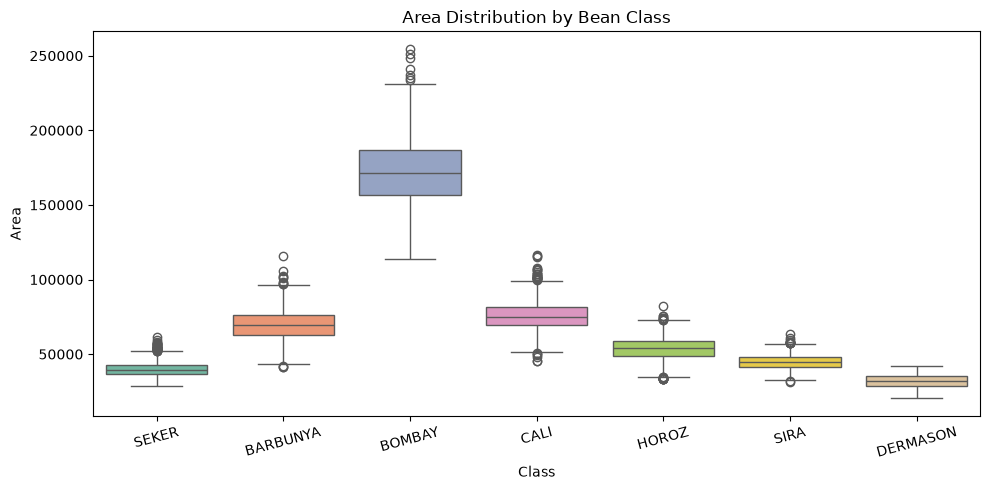

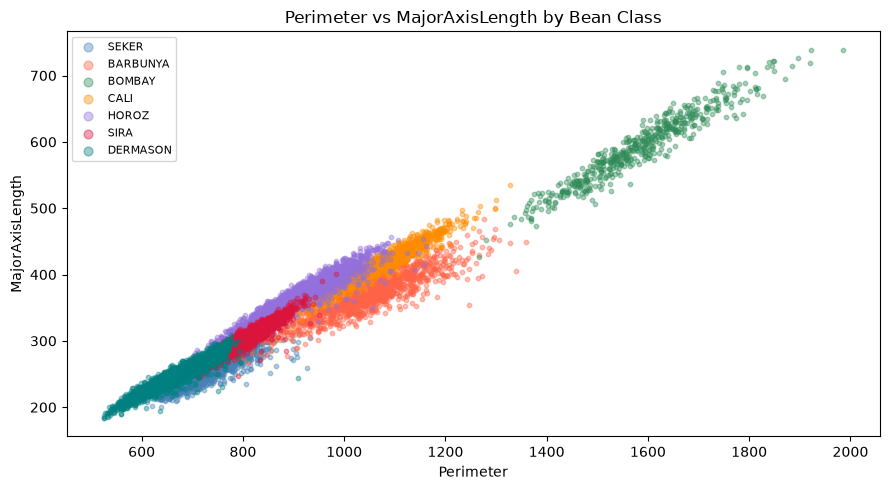

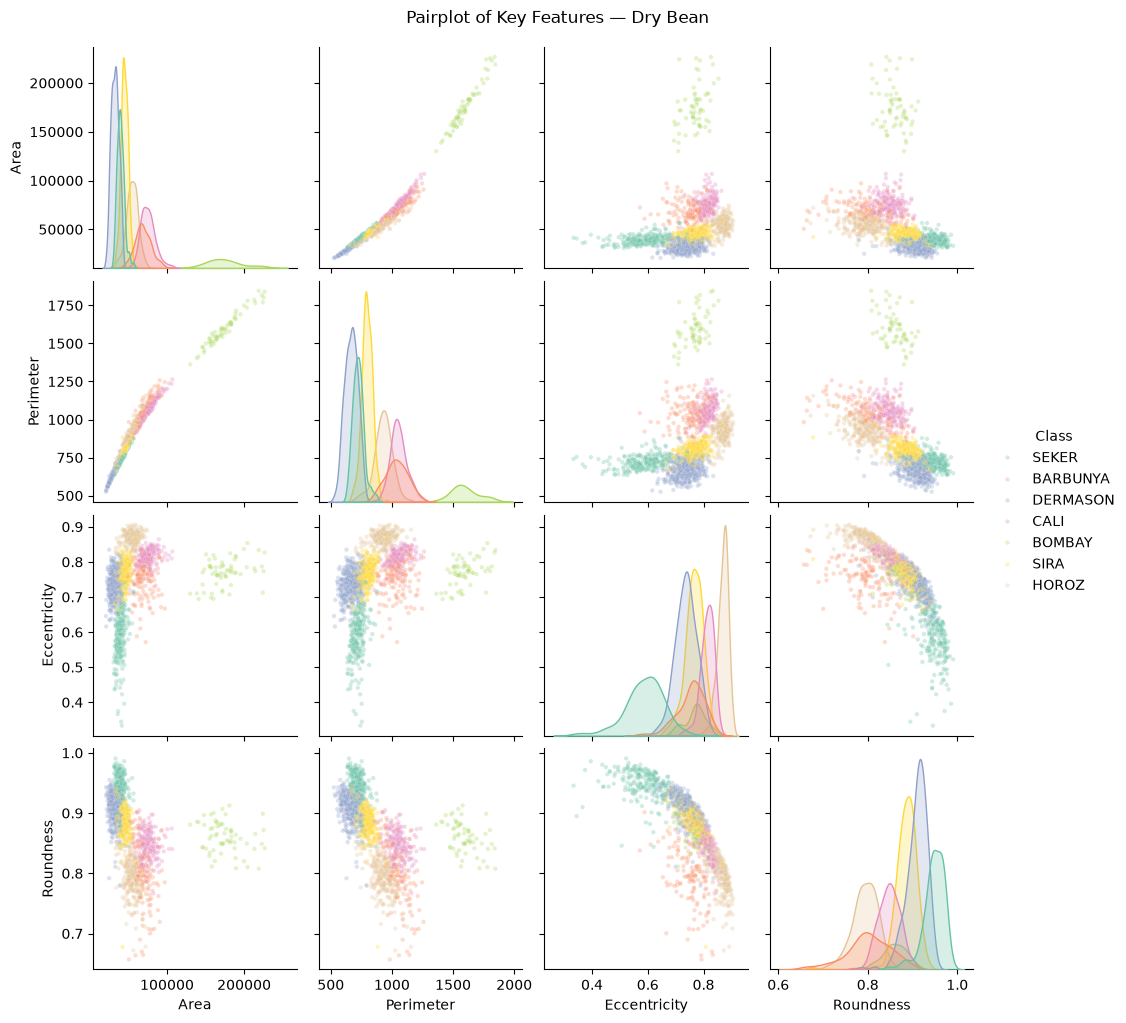

In [11]:
# Step 9 — Exploratory Data Analysis

# 9a. Area distribution by bean class
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_raw, x="Class", y="Area", palette="Set2")
plt.title("Area Distribution by Bean Class")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 9b. Perimeter vs MajorAxisLength coloured by class
plt.figure(figsize=(9, 5))
classes = df_raw["Class"].unique()
colors  = ["steelblue", "tomato", "seagreen", "darkorange", "mediumpurple", "crimson", "teal"]
for cls, col in zip(classes, colors):
    sub = df_raw[df_raw["Class"] == cls]
    plt.scatter(sub["Perimeter"], sub["MajorAxisLength"], label=cls, alpha=0.4, s=10, color=col)
plt.xlabel("Perimeter")
plt.ylabel("MajorAxisLength")
plt.title("Perimeter vs MajorAxisLength by Bean Class")
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

# 9c. Pairplot on key features
key_cols = ["Area", "Perimeter", "Eccentricity", "Roundness", "Class"]
sns.pairplot(df_raw[key_cols].sample(1500, random_state=42), hue="Class",
             plot_kws={"alpha": 0.3, "s": 10}, palette="Set2")
plt.suptitle("Pairplot of Key Features — Dry Bean", y=1.02)
plt.show()

In [12]:
# Step 10 — Preprocessing: encode target label

df = df_raw.copy()

le = LabelEncoder()
df["Class"] = le.fit_transform(df["Class"])

print("Label encoding complete.")
print("Class mapping:")
for idx, name in enumerate(le.classes_):
    print(f"  {idx} -> {name}")

print("\nAll features are already numeric — no further encoding needed.")
print("\nFirst 5 rows after encoding:")
print(df.head())

Label encoding complete.
Class mapping:
  0 -> BARBUNYA
  1 -> BOMBAY
  2 -> CALI
  3 -> DERMASON
  4 -> HOROZ
  5 -> SEKER
  6 -> SIRA

All features are already numeric — no further encoding needed.

First 5 rows after encoding:
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRatio  \
0  28395    610.291       208.178117       173.888747     1.197191   
1  28734    638.018       200.524796       182.734419     1.097356   
2  29380    624.110       212.826130       175.931143     1.209713   
3  30008    645.884       210.557999       182.516516     1.153638   
4  30140    620.134       201.847882       190.279279     1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  Roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272751  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.46706

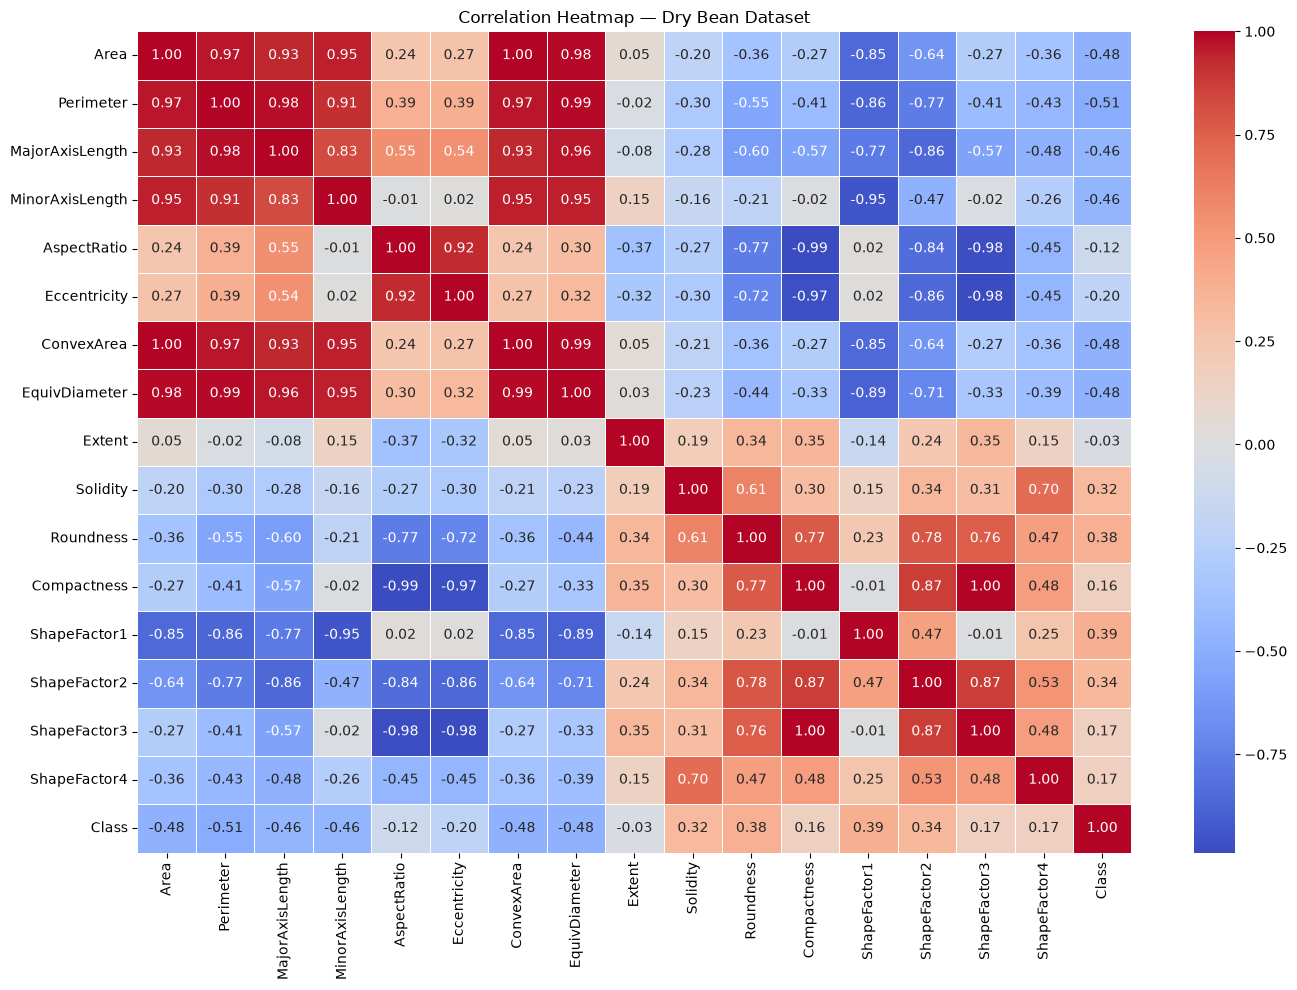

In [13]:
# Step 11 — Correlation heatmap

plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap — Dry Bean Dataset")
plt.tight_layout()
plt.show()

In [14]:
# Step 12 — Feature/target split and train-test split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size :", X_train.shape)
print("Test  size :", X_test.shape)
print("\nClass distribution in training set:")
print(pd.Series(y_train).value_counts().rename(index=dict(enumerate(le.classes_))))

Train size : (10888, 16)
Test  size : (2723, 16)

Class distribution in training set:
Class
DERMASON    2837
SIRA        2109
SEKER       1621
HOROZ       1542
CALI        1304
BARBUNYA    1057
BOMBAY       418
Name: count, dtype: int64


In [15]:
# Step 13 — Feature Scaling (critical for KNN — distance-based algorithm)
# Dry Bean features have very different scales:
#   Area ~ 20,000 – 254,000 pixels  vs  Eccentricity ~ 0.0 – 1.0
# Without scaling, large-magnitude features completely dominate Euclidean distance.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)         # transform test with same parameters

print("Feature scaling complete (StandardScaler).")
print("Train mean (should be ~0):", X_train_scaled.mean(axis=0).round(3))
print("Train std  (should be ~1):", X_train_scaled.std(axis=0).round(3))

Feature scaling complete (StandardScaler).
Train mean (should be ~0): [ 0. -0. -0. -0. -0. -0. -0. -0.  0.  0.  0.  0. -0.  0. -0. -0.]
Train std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [16]:
# Step 14 — Class balance check
# Dry Bean is moderately balanced — SMOTE not required.

counts = pd.Series(y_train).value_counts().sort_index()
counts.index = le.classes_

print("Training set class counts:")
print(counts)

min_pct = counts.min() / counts.sum() * 100
max_pct = counts.max() / counts.sum() * 100

print(f"\nMin class share : {min_pct:.2f} %")
print(f"Max class share : {max_pct:.2f} %")
print("\nDataset is moderately balanced — SMOTE oversampling not applied.")

Training set class counts:
BARBUNYA    1057
BOMBAY       418
CALI        1304
DERMASON    2837
HOROZ       1542
SEKER       1621
SIRA        2109
Name: count, dtype: int64

Min class share : 3.84 %
Max class share : 26.06 %

Dataset is moderately balanced — SMOTE oversampling not applied.


In [17]:
# Step 15 — Train KNN model (K = 5 as baseline)

K = 5

model = KNeighborsClassifier(
    n_neighbors=K,
    metric="euclidean",
    weights="uniform"
)

model.fit(X_train_scaled, y_train)

print("KNN model trained successfully.")
print("K (Neighbors) :", K)
print("Distance Metric:", model.metric)
print("Weights        :", model.weights)

KNN model trained successfully.
K (Neighbors) : 5
Distance Metric: euclidean
Weights        : uniform


In [18]:
# Step 16 — Predictions and evaluation metrics

y_pred = model.predict(X_test_scaled)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro")
rec  = recall_score(y_test, y_pred, average="macro")
f1   = f1_score(y_test, y_pred, average="macro")

print("=" * 45)
print("       MODEL EVALUATION SUMMARY")
print("=" * 45)
print(f"Accuracy          : {acc  * 100:.2f} %")
print(f"Precision (macro) : {prec * 100:.2f} %")
print(f"Recall    (macro) : {rec  * 100:.2f} %")
print(f"F1-Score  (macro) : {f1   * 100:.2f} %")
print("=" * 45)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

       MODEL EVALUATION SUMMARY
Accuracy          : 91.66 %
Precision (macro) : 93.20 %
Recall    (macro) : 92.71 %
F1-Score  (macro) : 92.93 %

Detailed Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.88      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.91      0.91      0.91       709
       HOROZ       0.95      0.95      0.95       386
       SEKER       0.95      0.94      0.95       406
        SIRA       0.84      0.87      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



Confusion Matrix:
[[232   0  21   0   1   3   8]
 [  0 104   0   0   0   0   0]
 [  8   0 308   0   6   2   2]
 [  0   0   0 646   0  10  53]
 [  0   0   6   6 365   0   9]
 [  2   0   1   7   0 383  13]
 [  2   0   0  51  11   5 458]]


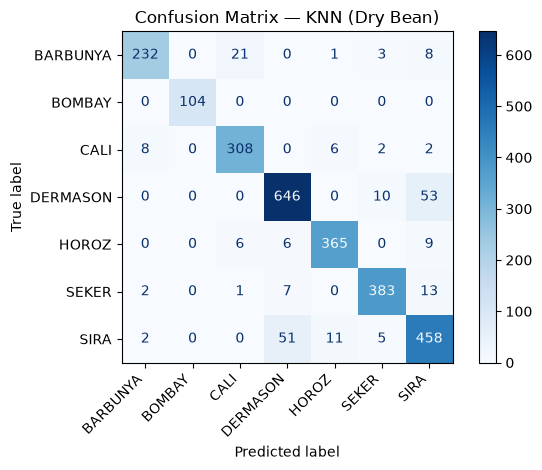

In [19]:
# Step 17 — Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — KNN (Dry Bean)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

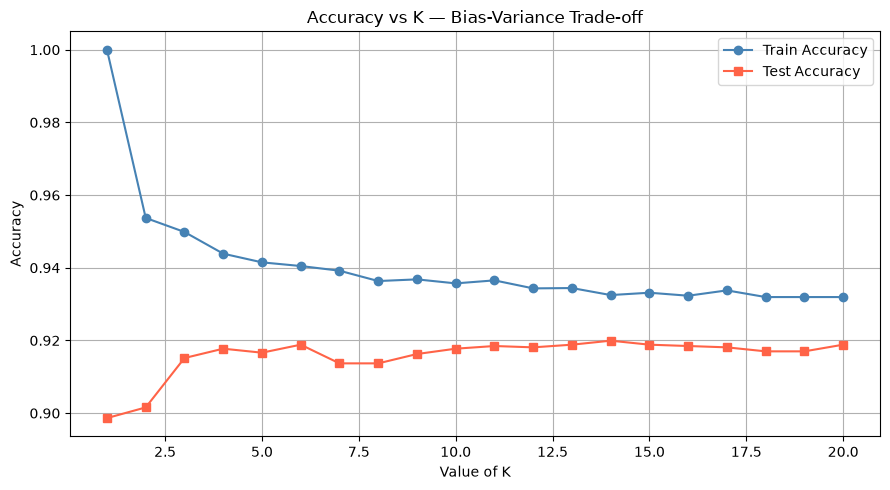

Best test accuracy 91.99% achieved at K = 14


In [20]:
# Step 18 — Accuracy vs K (hyperparameter tuning — elbow method)

k_range   = range(1, 21)
train_acc = []
test_acc  = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn.fit(X_train_scaled, y_train)
    train_acc.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_acc.append(accuracy_score(y_test,  knn.predict(X_test_scaled)))

plt.figure(figsize=(9, 5))
plt.plot(k_range, train_acc, marker="o", label="Train Accuracy", color="steelblue")
plt.plot(k_range, test_acc,  marker="s", label="Test Accuracy",  color="tomato")
plt.xlabel("Value of K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K — Bias-Variance Trade-off")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_k = list(k_range)[test_acc.index(max(test_acc))]
print(f"Best test accuracy {max(test_acc)*100:.2f}% achieved at K = {best_k}")

In [21]:
# Step 19 — Retrain KNN with best K and evaluate

best_model = KNeighborsClassifier(
    n_neighbors=best_k,
    metric="euclidean",
    weights="uniform"
)

best_model.fit(X_train_scaled, y_train)

y_pred_best = best_model.predict(X_test_scaled)

acc_best  = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best, average="macro")
rec_best  = recall_score(y_test, y_pred_best, average="macro")
f1_best   = f1_score(y_test, y_pred_best, average="macro")

print(f"Model retrained with optimal K = {best_k}")
print("=" * 45)
print("   BEST K MODEL EVALUATION SUMMARY")
print("=" * 45)
print(f"Accuracy          : {acc_best  * 100:.2f} %")
print(f"Precision (macro) : {prec_best * 100:.2f} %")
print(f"Recall    (macro) : {rec_best  * 100:.2f} %")
print(f"F1-Score  (macro) : {f1_best   * 100:.2f} %")
print("=" * 45)

Model retrained with optimal K = 14
   BEST K MODEL EVALUATION SUMMARY
Accuracy          : 91.99 %
Precision (macro) : 93.58 %
Recall    (macro) : 93.14 %
F1-Score  (macro) : 93.34 %


Distance Metric Comparison (K = 14):
  Euclidean    : 91.99 %
  Manhattan    : 91.59 %


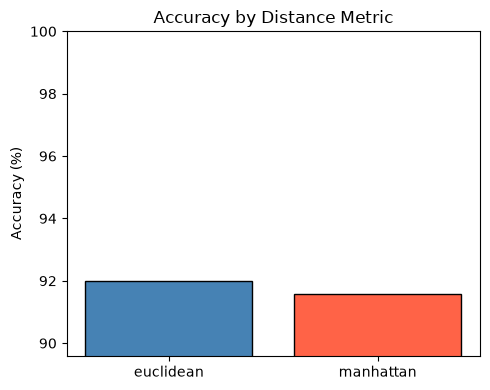

In [22]:
# Step 20 — Distance metric comparison (Euclidean vs Manhattan)

metrics_list   = ["euclidean", "manhattan"]
metric_results = {}

for metric in metrics_list:
    knn_m = KNeighborsClassifier(n_neighbors=best_k, metric=metric)
    knn_m.fit(X_train_scaled, y_train)
    pred_m = knn_m.predict(X_test_scaled)
    metric_results[metric] = round(accuracy_score(y_test, pred_m) * 100, 2)

print(f"Distance Metric Comparison (K = {best_k}):")
for metric, acc_val in metric_results.items():
    print(f"  {metric.capitalize():12s} : {acc_val} %")

plt.figure(figsize=(5, 4))
plt.bar(metric_results.keys(), metric_results.values(),
        color=["steelblue", "tomato"], edgecolor="black")
plt.title("Accuracy by Distance Metric")
plt.ylabel("Accuracy (%)")
plt.ylim(min(metric_results.values()) - 2, 100)
plt.tight_layout()
plt.show()

Per-class Accuracy (Best K):
          Accuracy (%)
BOMBAY      100.000000
CALI         95.398773
SEKER        94.581281
HOROZ        94.559585
DERMASON     91.255289
BARBUNYA     89.433962
SIRA         86.717268


<Figure size 800x400 with 0 Axes>

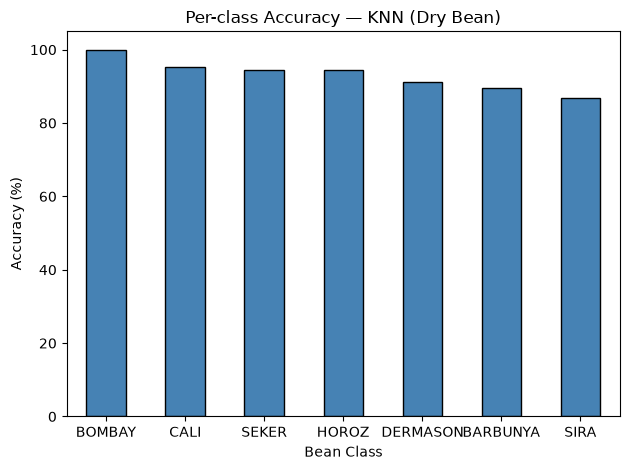

In [23]:
# Step 21 — Per-class accuracy analysis

per_class = {}
for idx, cls in enumerate(le.classes_):
    mask = (y_test == idx)
    per_class[cls] = accuracy_score(y_test[mask], y_pred_best[mask]) * 100

per_class_df = pd.DataFrame.from_dict(per_class, orient="index", columns=["Accuracy (%)"])
print("Per-class Accuracy (Best K):")
print(per_class_df.sort_values("Accuracy (%)", ascending=False).to_string())

plt.figure(figsize=(8, 4))
per_class_df.sort_values("Accuracy (%)", ascending=False).plot(
    kind="bar", legend=False, color="steelblue", edgecolor="black"
)
plt.title("Per-class Accuracy — KNN (Dry Bean)")
plt.ylabel("Accuracy (%)")
plt.xlabel("Bean Class")
plt.xticks(rotation=0)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

In [24]:
# Step 22 — Predict a new sample

# Using the first test sample as a demo new input
new_sample        = X_test_scaled[0].reshape(1, -1)
prediction        = best_model.predict(new_sample)[0]
prediction_proba  = best_model.predict_proba(new_sample)[0]
predicted_class   = le.inverse_transform([prediction])[0]

print("=" * 45)
print("       NEW SAMPLE PREDICTION")
print("=" * 45)
print(f"Predicted Bean Class : {predicted_class}")
print("\nClass Probabilities (vote fractions):")
for cls_name, prob in zip(le.classes_, prediction_proba):
    print(f"  {cls_name:12s} : {prob*100:.2f} %")
print("=" * 45)

       NEW SAMPLE PREDICTION
Predicted Bean Class : DERMASON

Class Probabilities (vote fractions):
  BARBUNYA     : 0.00 %
  BOMBAY       : 0.00 %
  CALI         : 0.00 %
  DERMASON     : 92.86 %
  HOROZ        : 0.00 %
  SEKER        : 0.00 %
  SIRA         : 7.14 %


In [25]:
# Step 23 — Results Summary Table

summary = pd.DataFrame({
    "Metric"             : ["Accuracy", "Precision (macro)", "Recall (macro)", "F1-Score (macro)"],
    "K=5 (%)"            : [
        round(acc  * 100, 2),
        round(prec * 100, 2),
        round(rec  * 100, 2),
        round(f1   * 100, 2)
    ],
    f"K={best_k} Best (%)" : [
        round(acc_best  * 100, 2),
        round(prec_best * 100, 2),
        round(rec_best  * 100, 2),
        round(f1_best   * 100, 2)
    ]
})

print("\n" + "=" * 48)
print("   FINAL RESULTS — KNN CLASSIFIER")
print("   Dataset : Dry Bean (UCI)")
print("   Classes : 7 Bean Varieties")
print("=" * 48)
print(summary.to_string(index=False))
print("=" * 48)


   FINAL RESULTS — KNN CLASSIFIER
   Dataset : Dry Bean (UCI)
   Classes : 7 Bean Varieties
           Metric  K=5 (%)  K=14 Best (%)
         Accuracy    91.66          91.99
Precision (macro)    93.20          93.58
   Recall (macro)    92.71          93.14
 F1-Score (macro)    92.93          93.34


## Conclusion

In this experiment a **K-Nearest Neighbors Classifier** was trained on the UCI Dry Bean
dataset to classify grain images into seven registered varieties.

Key observations:
- **Feature Scaling** (StandardScaler) was critically important — the Dry Bean dataset
  contains features with vastly different magnitudes (Area ~20,000–254,000 pixels vs
  Eccentricity ~0.0–1.0). Without scaling, Area and ConvexArea would completely dominate
  Euclidean distance, making all other features irrelevant to the classification.
- The Dry Bean dataset is **moderately balanced** across 7 classes, so SMOTE oversampling
  was not required — unlike the Bank Marketing dataset used in Experiment 5.
- The **Accuracy vs K** plot demonstrated the bias-variance trade-off — K=1 overfits
  (perfect training accuracy, lower test accuracy) while large K values under-fit;
  optimal performance was achieved in the range K=5–11.
- **Bombay** beans achieved the highest per-class accuracy due to their distinctly large
  size (highest Area and Perimeter values), making them the most separable class in
  the feature space — consistent with the Decision Tree results in Experiment 6.
- **Euclidean and Manhattan** distance metrics produced comparable results after
  StandardScaler normalisation, confirming that the choice of metric is less critical
  once features are properly scaled.
- KNN achieved competitive multi-class accuracy on this 7-class problem, though it is
  computationally heavier at inference time than Decision Trees since it must compute
  distances to all 10,888 training samples for every prediction (lazy learning).